<a href="https://colab.research.google.com/github/rSith/machine-learning-specialization/blob/rSith-dev/ML_Specialization_03_Classification_with_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification with Logistic Regression — Week 3

In [1]:
import copy, math
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=3)

In [2]:
def plot_data(X, y, ax, s=80):
    y = np.asarray(y).reshape(-1)
    pos, neg = y == 1, y == 0
    ax.scatter(X[pos, 0], X[pos, 1], marker='x', s=s, c='red', label="y=1")
    ax.scatter(X[neg, 0], X[neg, 1], marker='o', s=s + 20, facecolors='none',
               edgecolors='#0096ff', lw=3, label="y=0")
    ax.legend()

## 1. Classification

> **Classification** is a supervised learning task where the output $y$ can only take a small number of values (classes), instead of any number as in regression.

### 1.1 Classification problems

- Is an email **spam** or **not spam**?
- Is a tumor **malignant** or **benign**?

These are examples of **binary classification**: there are only two possible outcomes. They are written as pairs such as yes/no, true/false or **1/0**:
- $y = 1$ is the **positive class** (e.g. malignant, spam). "Positive" means *the thing we are looking for*, not "good".
- $y = 0$ is the **negative class**.

### 1.2 Datasets

We use two tiny datasets in this notebook:
- **1 feature** — tumor size $x$ vs malignant ($y$)
- **2 features** — $x_0, x_1$ vs label $y$ (used for the decision boundary, cost and gradient descent)

In [3]:
x_tumor = np.array([0., 1, 2, 3, 4, 5])                                          # (m,)
y_tumor = np.array([0,  0, 0, 1, 1, 1])
X_train = np.array([[0.5, 1.5], [1, 1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])  # (m, n)
y_train = np.array([0, 0, 0, 1, 1, 1])                                           # (m,)
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

X_train shape: (6, 2), y_train shape: (6,)


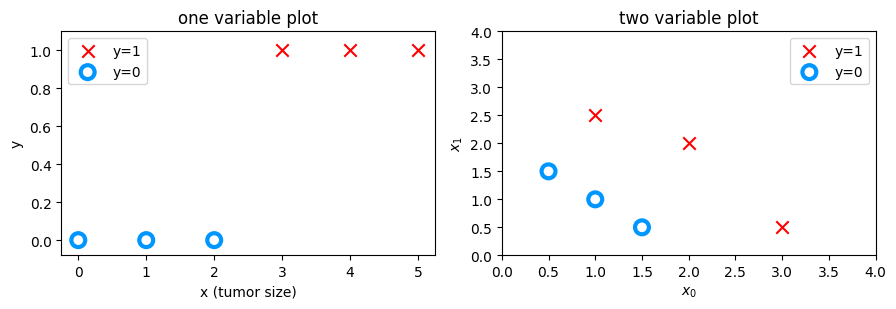

In [4]:
pos, neg = y_tumor == 1, y_tumor == 0
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))

# plot 1: one feature -> y can be drawn on the vertical axis
ax[0].scatter(x_tumor[pos], y_tumor[pos], marker='x', s=80, c='red', label="y=1")
ax[0].scatter(x_tumor[neg], y_tumor[neg], marker='o', s=100, facecolors='none',
              edgecolors='#0096ff', lw=3, label="y=0")
ax[0].set_ylim(-0.08, 1.1); ax[0].set_xlabel('x (tumor size)'); ax[0].set_ylabel('y')
ax[0].set_title('one variable plot'); ax[0].legend()

# plot 2: two features -> y is shown by the marker symbol
plot_data(X_train, y_train, ax[1])
ax[1].axis([0, 4, 0, 4]); ax[1].set_xlabel('$x_0$'); ax[1].set_ylabel('$x_1$')
ax[1].set_title('two variable plot')
plt.tight_layout(); plt.show()

- **One-variable plot:** positive results are red X's at $y=1$; negative results are blue O's at $y=0$. In linear regression $y$ could be *any* value; here it is only 0 or 1.
- **Two-variable plot:** there is no $y$ axis. The label is shown by the symbol instead. (With linear regression, the same plot would need a third dimension for $y$.)

### 1.3 Why not use linear regression?

Let's try it. We fit a straight line $f(x) = wx + b$ to the tumor data, then add a **threshold**: predict $y=1$ when $f(x) \ge 0.5$.

Then we add a few very large malignant tumors ($x = 8, 9, 10$) and fit again. (The course does this with an interactive plot; here `np.polyfit` gives the least-squares line directly.)

original data              predictions: [0 0 0 1 1 1]  targets: [0 0 0 1 1 1]
after adding x = 8, 9, 10  predictions: [0 0 0 0 1 1 1 1 1]  targets: [0 0 0 1 1 1 1 1 1]


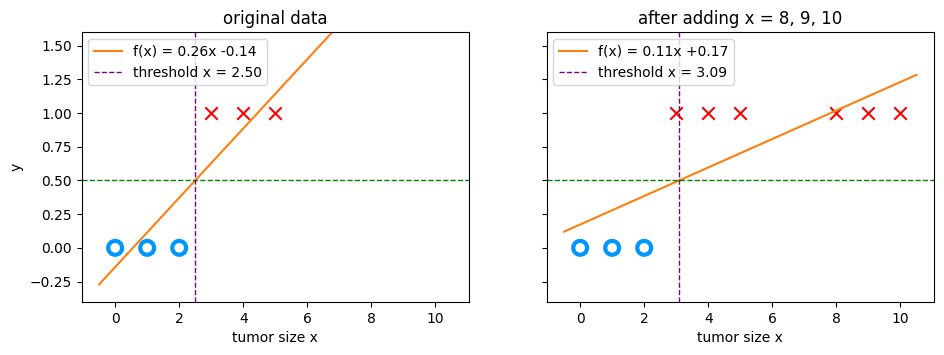

In [5]:
def fit_line(x, y):
    w, b = np.polyfit(x, y, 1)          # least-squares straight line
    return w, b

x_more = np.append(x_tumor, [8., 9., 10.])    # three extra, very large malignant tumors
y_more = np.append(y_tumor, [1, 1, 1])

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
for a, x, y, title in [(ax[0], x_tumor, y_tumor, "original data"),
                       (ax[1], x_more,  y_more,  "after adding x = 8, 9, 10")]:
    w, b = fit_line(x, y)
    x_thresh = (0.5 - b) / w                         # where the line crosses 0.5
    xs = np.linspace(-0.5, 10.5, 100)
    a.plot(xs, w * xs + b, c='tab:orange', label=f"f(x) = {w:.2f}x {b:+.2f}")
    a.axhline(0.5, c='g', ls='--', lw=1)
    a.axvline(x_thresh, c='purple', ls='--', lw=1, label=f"threshold x = {x_thresh:.2f}")
    p, n = y == 1, y == 0
    a.scatter(x[p], y[p], marker='x', s=80, c='red')
    a.scatter(x[n], y[n], marker='o', s=100, facecolors='none', edgecolors='#0096ff', lw=3)
    preds = (w * x + b >= 0.5).astype(int)
    print(f"{title:26s} predictions: {preds}  targets: {y}")
    a.set_title(title); a.set_xlabel("tumor size x"); a.set_ylim(-0.4, 1.6); a.legend(loc="upper left")
ax[0].set_ylabel("y")
plt.show()

**Observation.** On the original data the threshold sits between 2 and 3, and every prediction is right. Adding a few far-away malignant tumors (which are *easy* to classify!) tilts the line, the threshold moves right, and the tumor at $x = 3$ is now **wrongly predicted as benign**.

Linear regression is not suitable for classification because:
- it predicts continuous numbers, not classes, and its output can be less than 0 or greater than 1;
- a single extreme example can move the decision threshold and break correct predictions.

Classification needs an output between 0 and 1 that can be read as a **probability**. Logistic regression does this with the **sigmoid function**.

## 2. Sigmoid (logistic) function

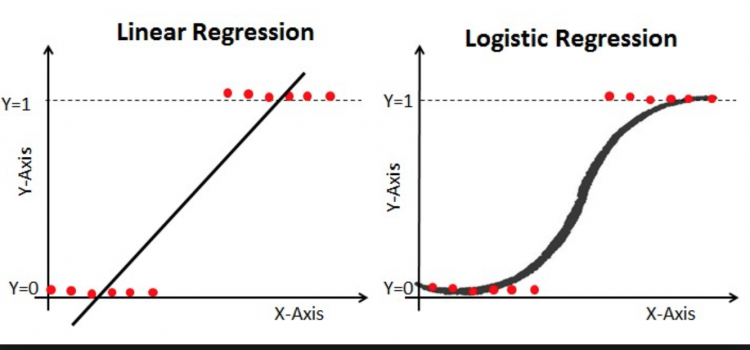

### 2.1 Formula

$$g(z) = \frac{1}{1+e^{-z}} \qquad 0 < g(z) < 1 \tag{1}$$

In logistic regression, $z$ is the output of the linear model, $z = \mathbf{w}\cdot\mathbf{x} + b$.
- For a single example, $z$ is a scalar.
- For $m$ examples, $z$ is a vector of $m$ values (one per example).

So `sigmoid` must work for both. NumPy's `np.exp()` already does: it computes $e^{z}$ element-wise for an array, and also works on a single number.

In [6]:
input_array = np.array([1, 2, 3])
print("Input to exp: ", input_array, " Output of exp:", np.exp(input_array))
print("Input to exp: ", 1, "        Output of exp:", np.exp(1))

Input to exp:  [1 2 3]  Output of exp: [ 2.718  7.389 20.086]
Input to exp:  1         Output of exp: 2.718281828459045


In [7]:
def sigmoid(z):
    """Sigmoid of z. Works for a scalar or a numpy array of any shape."""
    return 1 / (1 + np.exp(-z))

Let's look at the output for a range of $z$ values.

In [8]:
z_tmp = np.arange(-10, 11)
y_sig = sigmoid(z_tmp)
print("Input (z), Output (sigmoid(z))")
print(np.c_[z_tmp, y_sig])

Input (z), Output (sigmoid(z))
[[-1.000e+01  4.540e-05]
 [-9.000e+00  1.234e-04]
 [-8.000e+00  3.354e-04]
 [-7.000e+00  9.111e-04]
 [-6.000e+00  2.473e-03]
 [-5.000e+00  6.693e-03]
 [-4.000e+00  1.799e-02]
 [-3.000e+00  4.743e-02]
 [-2.000e+00  1.192e-01]
 [-1.000e+00  2.689e-01]
 [ 0.000e+00  5.000e-01]
 [ 1.000e+00  7.311e-01]
 [ 2.000e+00  8.808e-01]
 [ 3.000e+00  9.526e-01]
 [ 4.000e+00  9.820e-01]
 [ 5.000e+00  9.933e-01]
 [ 6.000e+00  9.975e-01]
 [ 7.000e+00  9.991e-01]
 [ 8.000e+00  9.997e-01]
 [ 9.000e+00  9.999e-01]
 [ 1.000e+01  1.000e+00]]


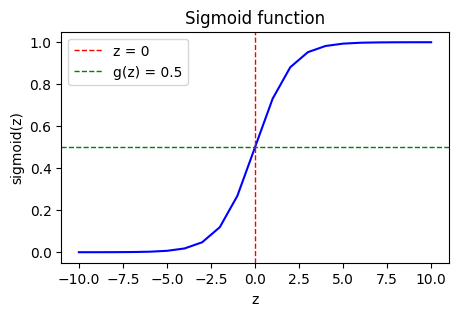

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(z_tmp, y_sig, c="b")
ax.axvline(0, color='r', ls='--', lw=1, label="z = 0")
ax.axhline(0.5, color='g', ls='--', lw=1, label="g(z) = 0.5")
ax.set_title("Sigmoid function"); ax.set_xlabel('z'); ax.set_ylabel('sigmoid(z)')
ax.legend(); plt.show()

**Observation.**
- $g(z) \to 0$ as $z \to -\infty$ and $g(z) \to 1$ as $z \to +\infty$.
- $g(0) = 0.5$ exactly, and $g(z) \ge 0.5$ **exactly when** $z \ge 0$. This fact gives us the decision boundary in Part 4.

## 3. Logistic regression model

A logistic regression model passes the familiar linear model through the sigmoid:

$$z = \mathbf{w}\cdot\mathbf{x} + b, \qquad f_{\mathbf{w},b}(\mathbf{x}) = g(z) = \frac{1}{1+e^{-(\mathbf{w}\cdot\mathbf{x} + b)}} \tag{2}$$

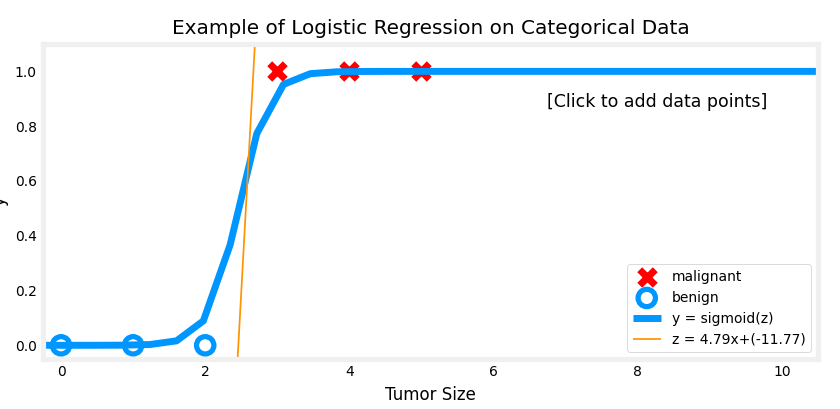

### 3.1 Interpreting the output

$f_{\mathbf{w},b}(\mathbf{x})$ is the **probability that $y = 1$**, given input $\mathbf{x}$ and parameters $\mathbf{w}, b$:

$$f_{\mathbf{w},b}(\mathbf{x}) = P(y = 1 \mid \mathbf{x};\, \mathbf{w}, b), \qquad P(y=0) = 1 - P(y=1)$$

Example: if $f = 0.7$ for a tumor, the model says there is a **70% chance it is malignant** (and 30% that it is benign).

In [10]:
def predict_proba(X, w, b):
    return sigmoid(X @ w + b)              # probability that y = 1, shape (m,)

def predict(X, w, b, threshold=0.5):
    return (predict_proba(X, w, b) >= threshold).astype(int)

## 4. Decision boundary

> A **decision boundary** is the line (or curve, or surface) that separates the region where the model predicts $y=1$ from the region where it predicts $y=0$.

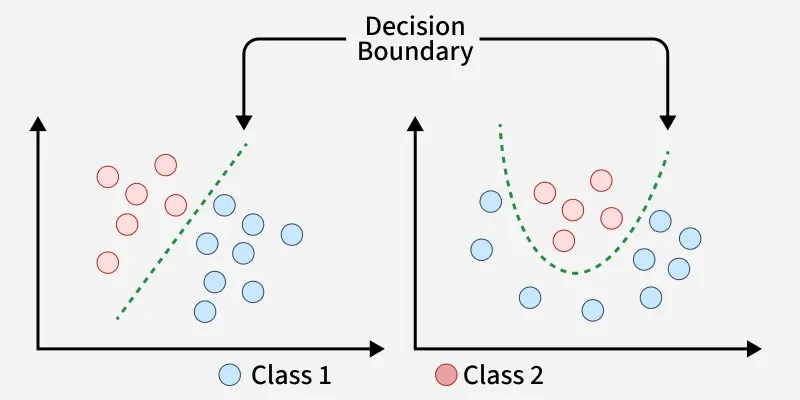

To turn a probability into a class we use a threshold of 0.5:

$$\hat{y} = \begin{cases} 1 & \text{if } f_{\mathbf{w},b}(\mathbf{x}) \ge 0.5 \\ 0 & \text{if } f_{\mathbf{w},b}(\mathbf{x}) < 0.5 \end{cases}$$

From Part 2, $g(z) \ge 0.5 \iff z \ge 0$. So:
- if $\mathbf{w}\cdot\mathbf{x} + b \ge 0$, the model predicts $y = 1$
- if $\mathbf{w}\cdot\mathbf{x} + b < 0$, the model predicts $y = 0$

The **decision boundary is where $z = \mathbf{w}\cdot\mathbf{x} + b = 0$.**

### 4.1 Linear decision boundary

Suppose training gave $w_0 = 1,\ w_1 = 1,\ b = -3$ (we will *learn* these values in Part 7). Then

$$f(\mathbf{x}) = g(x_0 + x_1 - 3)$$

which predicts $y=1$ when $x_0 + x_1 - 3 \ge 0$. The boundary is the straight line $x_0 + x_1 = 3$, i.e. $x_1 = 3 - x_0$.

probabilities: [0.269 0.269 0.269 0.622 0.731 0.622]
predictions:   [0 0 0 1 1 1]
targets:       [0 0 0 1 1 1]


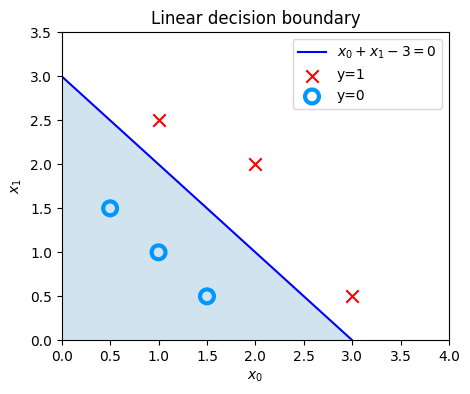

In [11]:
w_db = np.array([1., 1.])
b_db = -3.
print("probabilities:", predict_proba(X_train, w_db, b_db))
print("predictions:  ", predict(X_train, w_db, b_db))
print("targets:      ", y_train)

x0 = np.arange(0, 6)
x1 = 3 - x0                                    # decision boundary x0 + x1 - 3 = 0
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.plot(x0, x1, c="b", label="$x_0 + x_1 - 3 = 0$")
ax.fill_between(x0, x1, alpha=0.2)             # region below the line: z < 0  ->  y = 0
plot_data(X_train, y_train, ax)
ax.axis([0, 4, 0, 3.5]); ax.set_xlabel('$x_0$'); ax.set_ylabel('$x_1$')
ax.set_title("Linear decision boundary"); plt.show()

**Observation.**
- The blue line $x_0 + x_1 - 3 = 0$ meets both axes at 3 (set $x_0 = 0 \Rightarrow x_1 = 3$, and $x_1 = 0 \Rightarrow x_0 = 3$).
- The shaded region (below the line) is $z < 0$, so points there are predicted $y=0$. Points **on or above** the line are predicted $y=1$.
- Point $(3, 0.5)$ gives $z = 0.5$, so $f \approx 0.62$, which is just above the threshold. The model is *least* certain for points close to the boundary.

### 4.2 Non-linear decision boundary

With polynomial features (as in Week 2's feature engineering), the boundary can be a curve. For example, with $w_0 = w_1 = 1$, $b = -1$ on the features $x_0^2, x_1^2$:

$$f(\mathbf{x}) = g(x_0^2 + x_1^2 - 1)$$

The boundary $x_0^2 + x_1^2 = 1$ is a **circle of radius 1**: predict $y = 1$ outside it and $y = 0$ inside it.

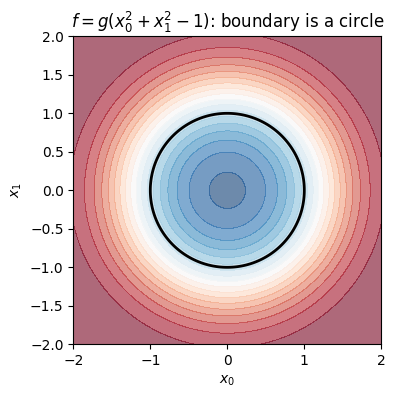

In [12]:
g0, g1 = np.meshgrid(np.linspace(-2, 2, 300), np.linspace(-2, 2, 300))
z_grid = g0**2 + g1**2 - 1

fig, ax = plt.subplots(1, 1, figsize=(4.5, 4))
ax.contourf(g0, g1, sigmoid(z_grid), levels=20, cmap="RdBu_r", alpha=0.6)
ax.contour(g0, g1, z_grid, levels=[0], colors="k", linewidths=2)   # z = 0 -> the boundary
ax.set_aspect("equal"); ax.set_xlabel("$x_0$"); ax.set_ylabel("$x_1$")
ax.set_title("$f = g(x_0^2 + x_1^2 - 1)$: boundary is a circle"); plt.show()

Colour shows the probability $f$ (blue ≈ 0, red ≈ 1). Higher-order terms give even more complex shapes, such as ellipses or irregular closed curves.

## 5. Logistic loss

### 5.1 Why not use squared error?

For **linear** regression we used the squared error cost:

$$J(w,b) = \frac{1}{2m} \sum_{i=0}^{m-1} \left(f_{w,b}(x^{(i)}) - y^{(i)}\right)^2 \tag{3}$$

With $f_{w,b}(x) = wx + b$ this gives a convex "soup bowl", so gradient descent always reaches the global minimum.

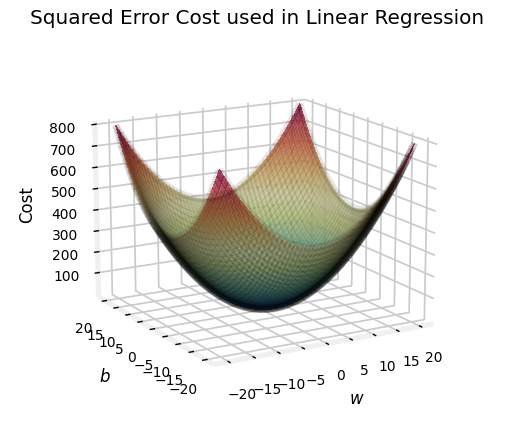

- It seems natural to reuse the same cost for logistic regression.
- But now $f_{w,b}(x^{(i)}) = g(wx^{(i)} + b)$ contains the **non-linear** sigmoid.
- Let's plot the squared error cost of the sigmoid model on the tumor data to see what happens.

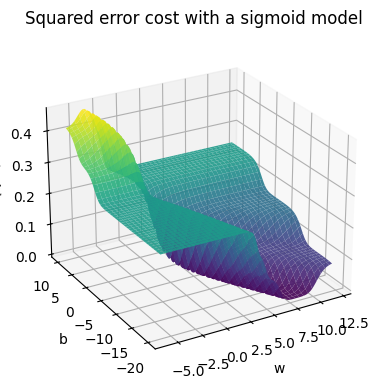

In [13]:
w_grid, b_grid = np.meshgrid(np.linspace(-6, 12, 120), np.linspace(-20, 10, 120))

def sq_err_cost_sigmoid(x, y, w, b):
    f = sigmoid(w * x + b)
    return np.mean((f - y) ** 2) / 2

J_sq = np.array([[sq_err_cost_sigmoid(x_tumor, y_tumor, w, b) for w, b in zip(wr, br)]
                 for wr, br in zip(w_grid, b_grid)])

fig = plt.figure(figsize=(6, 4.5))
ax = fig.add_subplot(projection='3d')
ax.plot_surface(w_grid, b_grid, J_sq, cmap="viridis", alpha=0.9)
ax.set_xlabel("w"); ax.set_ylabel("b"); ax.set_zlabel("J(w,b)")
ax.set_title("Squared error cost with a sigmoid model"); ax.view_init(25, -120)
plt.show()

**Observation.** This surface is **not convex**. It has flat plateaus where the gradient is almost zero and a narrow valley, so gradient descent can stall or get stuck. Logistic regression needs a cost that suits its non-linear model. We build it from a new **loss** function.

### 5.2 Logistic loss function

> **Definitions used in this course**
> - **Loss** $L$ measures the error on a **single** example.
> - **Cost** $J$ is the average of the losses over the **whole** training set.

$$L\left(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}\right) = \begin{cases}
  -\log\left(f_{\mathbf{w},b}(\mathbf{x}^{(i)})\right) & \text{if } y^{(i)} = 1 \\
  -\log\left(1 - f_{\mathbf{w},b}(\mathbf{x}^{(i)})\right) & \text{if } y^{(i)} = 0
\end{cases} \tag{4}$$

(`log` is the natural logarithm, `np.log`.)

The loss uses **two separate curves**, one for each target value. Both are 0 when the prediction matches the target, and grow quickly as the prediction moves away from it.

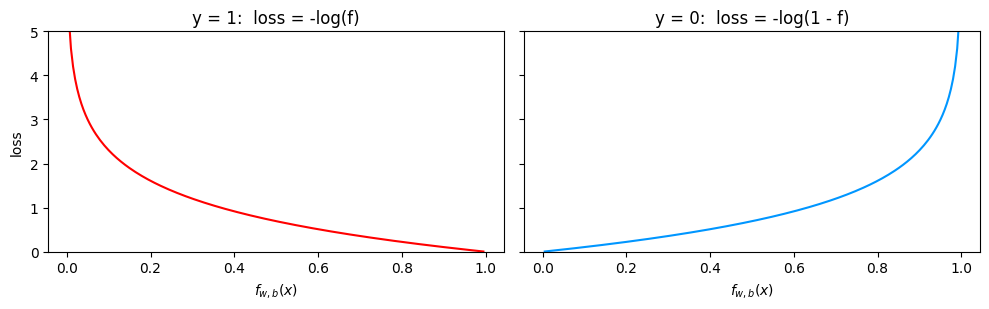

In [14]:
f = np.linspace(0.005, 0.995, 200)            # sigmoid outputs are strictly between 0 and 1
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
ax[0].plot(f, -np.log(f), c='red')
ax[0].set_title("y = 1:  loss = -log(f)"); ax[0].set_xlabel("$f_{w,b}(x)$"); ax[0].set_ylabel("loss")
ax[1].plot(f, -np.log(1 - f), c='#0096ff')
ax[1].set_title("y = 0:  loss = -log(1 - f)"); ax[1].set_xlabel("$f_{w,b}(x)$")
for a in ax: a.set_ylim(0, 5)
plt.tight_layout(); plt.show()

**Observation.**
- **$y = 1$:** if the model predicts $f \to 1$ the loss $\to 0$; if it predicts $f \to 0$ (confident *and* wrong) the loss $\to \infty$.
- **$y = 0$:** the mirror image. The loss is 0 at $f = 0$ and $\to \infty$ as $f \to 1$.
- Together they act like the squared error "bowl", but suited to outputs between 0 and 1. A confident wrong prediction is penalised very strongly.

### 5.3 Simplified loss (one line)

Because $y$ is always 0 or 1, the two cases can be written as one formula, which is easier to code:

$$L\left(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}\right) = -y^{(i)} \log\left(f_{\mathbf{w},b}(\mathbf{x}^{(i)})\right) - \left(1 - y^{(i)}\right) \log\left(1 - f_{\mathbf{w},b}(\mathbf{x}^{(i)})\right) \tag{5}$$

- $y^{(i)} = 1$: the second term is multiplied by $(1-1) = 0$ and disappears, leaving $-\log(f)$.
- $y^{(i)} = 0$: the first term is multiplied by $0$ and disappears, leaving $-\log(1 - f)$.

In [15]:
def logistic_loss(f, y):
    return -y * np.log(f) - (1 - y) * np.log(1 - f)

for f_val, y_val in [(0.9, 1), (0.1, 1), (0.1, 0), (0.9, 0)]:
    print(f"f = {f_val}, y = {y_val}  ->  loss = {logistic_loss(f_val, y_val):.3f}")

f = 0.9, y = 1  ->  loss = 0.105
f = 0.1, y = 1  ->  loss = 2.303
f = 0.1, y = 0  ->  loss = 0.105
f = 0.9, y = 0  ->  loss = 2.303


## 6. Cost function for logistic regression

The cost is the average loss over all $m$ examples:

$$J(\mathbf{w},b) = \frac{1}{m} \sum_{i=0}^{m-1} L\left(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}\right) \tag{6}$$

$$= -\frac{1}{m} \sum_{i=0}^{m-1} \left[ y^{(i)} \log\left(f_{\mathbf{w},b}(\mathbf{x}^{(i)})\right) + \left(1 - y^{(i)}\right) \log\left(1 - f_{\mathbf{w},b}(\mathbf{x}^{(i)})\right) \right]$$

where $f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = g(z^{(i)})$ and $z^{(i)} = \mathbf{w}\cdot\mathbf{x}^{(i)} + b$.

### 6.1 Implementation

The loop version (as in Lab 05) and the vectorized version give the same answer.

In [16]:
def compute_cost_logistic_loop(X, y, w, b):
    m = X.shape[0]
    cost = 0.0
    for i in range(m):
        f_wb_i = sigmoid(np.dot(X[i], w) + b)
        cost += -y[i] * np.log(f_wb_i) - (1 - y[i]) * np.log(1 - f_wb_i)
    return cost / m

def compute_cost_logistic(X, y, w, b):
    f_wb = sigmoid(X @ w + b)                          # shape (m,)
    return np.mean(-y * np.log(f_wb) - (1 - y) * np.log(1 - f_wb))

w_tmp, b_tmp = np.array([1, 1]), -3
print(f"loop:       {compute_cost_logistic_loop(X_train, y_train, w_tmp, b_tmp)}")
print(f"vectorized: {compute_cost_logistic(X_train, y_train, w_tmp, b_tmp)}")   # expected ≈ 0.3668667864055175

loop:       0.36686678640551745
vectorized: 0.36686678640551745


### 6.2 Comparing two models with the cost

Is $b = -4$ (with $w_0 = w_1 = 1$) a better model than $b = -3$? First, plot both decision boundaries.

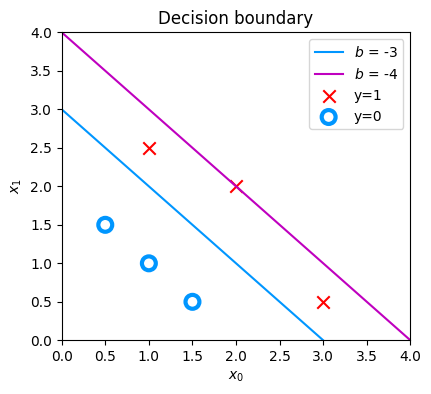

Cost for b = -3 : 0.36686678640551745
Cost for b = -4 : 0.5036808636748461


In [17]:
x0 = np.arange(0, 6)
fig, ax = plt.subplots(1, 1, figsize=(4.5, 4))
ax.plot(x0, 3 - x0, c='#0096ff', label="$b$ = -3")
ax.plot(x0, 4 - x0, c='m',       label="$b$ = -4")
plot_data(X_train, y_train, ax)
ax.axis([0, 4, 0, 4]); ax.set_xlabel('$x_0$'); ax.set_ylabel('$x_1$')
ax.legend(loc="upper right"); ax.set_title("Decision boundary"); plt.show()

for b_try in [-3, -4]:
    print(f"Cost for b = {b_try} : {compute_cost_logistic(X_train, y_train, np.array([1, 1]), b_try)}")
# expected:  b = -3 -> 0.3668667864055175,  b = -4 -> 0.5036808636748461

**Observation.** With $b = -4$ the boundary moves up: two positive points, $(3, 0.5)$ and $(1, 2.5)$, now fall below it and are misclassified, and $(2, 2)$ sits exactly on it ($z = 0$, $f = 0.5$). So it is a worse model. The cost agrees: it is higher for $b=-4$ (0.504) than for $b=-3$ (0.367).

### 6.3 The logistic cost surface is convex

Now we plot the **logistic** cost for the same one-feature tumor model as in 5.1.

> **Numerical note.** For large $|z|$, `sigmoid` rounds to exactly 0 or 1 and `np.log(0)` gives `-inf`. For this wide surface we use the algebraically equal stable form $L = \log(1 + e^{z}) - yz$, computed with `np.logaddexp(0, z)`.

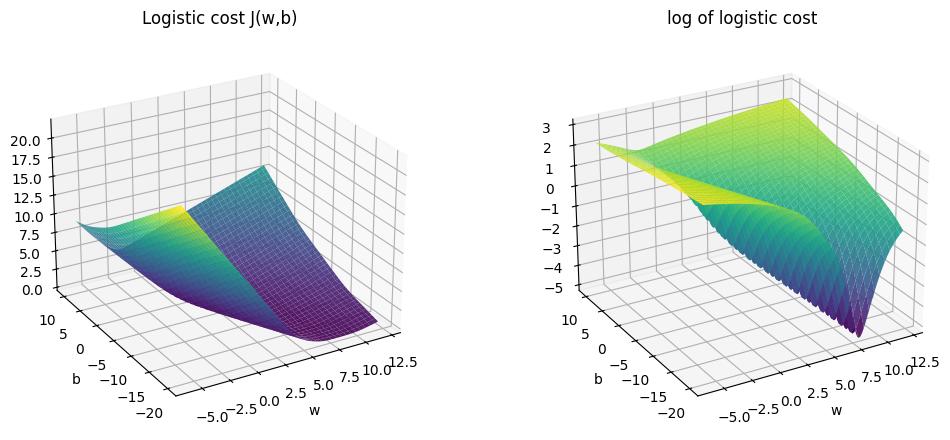

In [18]:
def cost_logistic_stable(x, y, w, b):
    z = w * x + b
    return np.mean(np.logaddexp(0, z) - y * z)

J_log = np.array([[cost_logistic_stable(x_tumor, y_tumor, w, b) for w, b in zip(wr, br)]
                  for wr, br in zip(w_grid, b_grid)])

fig = plt.figure(figsize=(11, 4.5))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(w_grid, b_grid, J_log, cmap="viridis", alpha=0.9)
ax1.set_title("Logistic cost J(w,b)"); ax1.view_init(25, -120)
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(w_grid, b_grid, np.log(J_log), cmap="viridis", alpha=0.9)
ax2.set_title("log of logistic cost"); ax2.view_init(25, -120)
for a in (ax1, ax2): a.set_xlabel("w"); a.set_ylabel("b")
plt.tight_layout(); plt.show()

**Observation.** Unlike the squared-error surface, this one has **no plateaus, local minima or jumps**, so it is well suited to gradient descent. It is not a perfect bowl: along the valley it keeps sloping gently downward. The log plot makes this visible. (On this perfectly separable data the cost only approaches 0 as $w$ grows, which is why the weights keep growing in Part 7.)

## 7. Gradient descent for logistic regression

Repeat until convergence, updating all parameters **simultaneously**:

$$w_j := w_j - \alpha \frac{\partial J(\mathbf{w},b)}{\partial w_j} \quad (j = 0..n-1), \qquad b := b - \alpha \frac{\partial J(\mathbf{w},b)}{\partial b} \tag{7}$$

$$\frac{\partial J(\mathbf{w},b)}{\partial w_j} = \frac{1}{m} \sum_{i=0}^{m-1} \left(f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}\right) x_j^{(i)}, \qquad
\frac{\partial J(\mathbf{w},b)}{\partial b} = \frac{1}{m} \sum_{i=0}^{m-1} \left(f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}\right) \tag{8}$$

> These look **exactly like the linear regression gradients** from Week 2. The only difference is the definition of $f$: here $f_{\mathbf{w},b}(\mathbf{x}) = g(\mathbf{w}\cdot\mathbf{x} + b)$ instead of $\mathbf{w}\cdot\mathbf{x} + b$. So the code only changes in one line.

### 7.1 Computing the gradient

Like the labs, the function returns `(dj_db, dj_dw)` in that order.

In [19]:
def compute_gradient_logistic(X, y, w, b):
    m = X.shape[0]
    err = sigmoid(X @ w + b) - y      # f_wb - y, shape (m,)   <- the only change from Week 2
    dj_dw = (X.T @ err) / m           # shape (n,)
    dj_db = np.sum(err) / m           # scalar
    return dj_db, dj_dw

X_tmp = np.array([[0.5, 1.5], [1, 1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y_tmp = np.array([0, 0, 0, 1, 1, 1])
dj_db_tmp, dj_dw_tmp = compute_gradient_logistic(X_tmp, y_tmp, np.array([2., 3.]), 1.)
print(f"dj_db: {dj_db_tmp}")             # expected 0.49861806546328574
print(f"dj_dw: {dj_dw_tmp.tolist()}")    # expected [0.498333393278696, 0.49883942983996693]

dj_db: 0.49861806546328574
dj_dw: [0.498333393278696, 0.49883942983996693]


### 7.2 Gradient descent loop

In [20]:
def gradient_descent(X, y, w_in, b_in, alpha, num_iters, verbose=True):
    w = copy.deepcopy(w_in)          # don't change the caller's array
    b = b_in
    J_history = []
    print_every = max(1, math.ceil(num_iters / 10))
    for i in range(num_iters):
        dj_db, dj_dw = compute_gradient_logistic(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        if i < 100000:               # prevent resource exhaustion
            J_history.append(compute_cost_logistic(X, y, w, b))
        if verbose and (i % print_every == 0 or i == num_iters - 1):
            print(f"Iteration {i:5d}: Cost {J_history[-1]:.6f}")
    return w, b, J_history

In [21]:
w_out, b_out, J_hist = gradient_descent(X_train, y_train, np.zeros(2), 0., alpha=0.1, num_iters=10000)
print(f"\nupdated parameters: w: {w_out}, b: {b_out}")    # expected w ≈ [5.28 5.08], b ≈ -14.22
print("predictions:", predict(X_train, w_out, b_out), " targets:", y_train)

Iteration     0: Cost 0.684610
Iteration  1000: Cost 0.159098
Iteration  2000: Cost 0.084601
Iteration  3000: Cost 0.057053
Iteration  4000: Cost 0.042908
Iteration  5000: Cost 0.034338
Iteration  6000: Cost 0.028604
Iteration  7000: Cost 0.024502
Iteration  8000: Cost 0.021424
Iteration  9000: Cost 0.019030
Iteration  9999: Cost 0.017118

updated parameters: w: [5.281 5.078], b: -14.222409982019839
predictions: [0 0 0 1 1 1]  targets: [0 0 0 1 1 1]


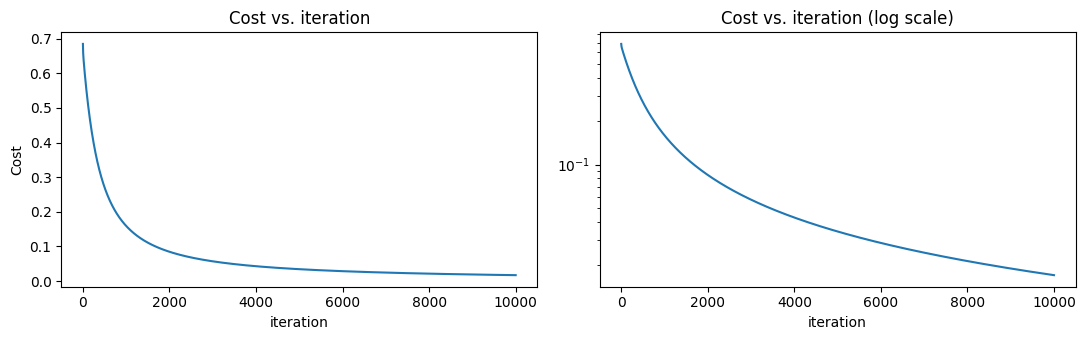

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(J_hist); ax[0].set_title("Cost vs. iteration")
ax[0].set_xlabel("iteration"); ax[0].set_ylabel("Cost")
ax[1].plot(J_hist); ax[1].set_yscale("log"); ax[1].set_title("Cost vs. iteration (log scale)")
ax[1].set_xlabel("iteration")
plt.tight_layout(); plt.show()

### 7.3 Plotting the result

- The **shading** shows the probability $f_{\mathbf{w},b}(\mathbf{x})$ that $y=1$ (before any threshold).
- The **decision boundary** is the line where the probability is 0.5, i.e. $w_0 x_0 + w_1 x_1 + b = 0$. Its intercepts are $x_0 = -b/w_0$ and $x_1 = -b/w_1$.

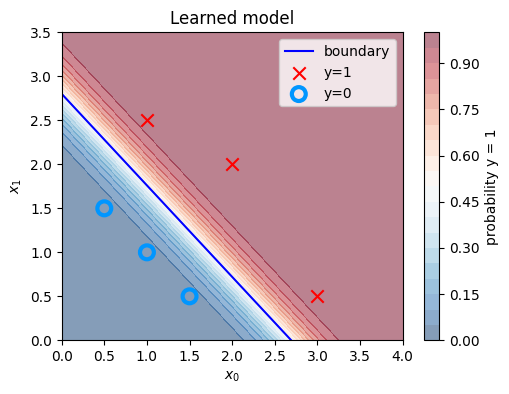

In [23]:
g0, g1 = np.meshgrid(np.linspace(0, 4, 200), np.linspace(0, 3.5, 200))
prob = sigmoid(w_out[0] * g0 + w_out[1] * g1 + b_out)

fig, ax = plt.subplots(1, 1, figsize=(5.5, 4))
cf = ax.contourf(g0, g1, prob, levels=20, cmap="RdBu_r", alpha=0.5)
fig.colorbar(cf, ax=ax, label="probability y = 1")
ax.plot([0, -b_out / w_out[0]], [-b_out / w_out[1], 0], c="b", lw=1.5, label="boundary")
plot_data(X_train, y_train, ax)
ax.axis([0, 4, 0, 3.5]); ax.set_xlabel('$x_0$'); ax.set_ylabel('$x_1$')
ax.set_title("Learned model"); plt.show()

**Observation.** Gradient descent found $w \approx [5.28, 5.08]$, $b \approx -14.22$. The boundary has almost the same slope as our hand-picked $x_0 + x_1 = 3$ (intercepts $-b/w_0 \approx 2.7$ and $-b/w_1 \approx 2.8$, vs 3), and all six points are classified correctly. Because the weights are large, the probability changes sharply from 0 to 1 across the boundary.

### 7.4 One feature: watching gradient descent on the cost contour

With one feature there are only two parameters, $w$ and $b$, so we can draw the cost as a contour plot and show the path gradient descent takes. (This replaces the interactive `plt_quad_logistic` plot from Lab 06.)

w = 8.130, b = -20.147, cost = 0.0058


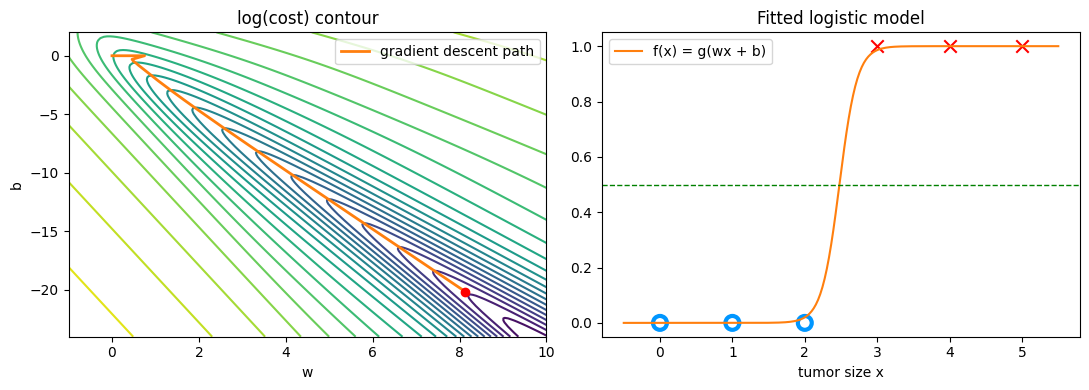

In [24]:
X_tumor = x_tumor.reshape(-1, 1)                 # (m, 1) so the same functions work
w_path, b_path = np.zeros(1), 0.
path = [(0., 0.)]
for _ in range(5000):
    dj_db, dj_dw = compute_gradient_logistic(X_tumor, y_tumor, w_path, b_path)
    w_path, b_path = w_path - 1.0 * dj_dw, b_path - 1.0 * dj_db
    path.append((w_path[0], b_path))
path = np.array(path)
print(f"w = {w_path[0]:.3f}, b = {b_path:.3f}, cost = {compute_cost_logistic(X_tumor, y_tumor, w_path, b_path):.4f}")

wg, bg = np.meshgrid(np.linspace(-1, 10, 150), np.linspace(-24, 2, 150))
J_c = np.array([[cost_logistic_stable(x_tumor, y_tumor, w, b) for w, b in zip(wr, br)]
                for wr, br in zip(wg, bg)])

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
cs = ax[0].contour(wg, bg, np.log(J_c), levels=25, cmap="viridis")
ax[0].plot(path[:, 0], path[:, 1], c='tab:orange', lw=2, label="gradient descent path")
ax[0].scatter(*path[-1], c='r', zorder=3)
ax[0].set_xlabel("w"); ax[0].set_ylabel("b"); ax[0].set_title("log(cost) contour"); ax[0].legend()

xs = np.linspace(-0.5, 5.5, 200)
ax[1].plot(xs, sigmoid(w_path[0] * xs + b_path), c='tab:orange', label="f(x) = g(wx + b)")
ax[1].axhline(0.5, c='g', ls='--', lw=1)
ax[1].scatter(x_tumor[y_tumor == 1], y_tumor[y_tumor == 1], marker='x', s=80, c='red')
ax[1].scatter(x_tumor[y_tumor == 0], y_tumor[y_tumor == 0], marker='o', s=100,
              facecolors='none', edgecolors='#0096ff', lw=3)
ax[1].set_xlabel("tumor size x"); ax[1].set_title("Fitted logistic model"); ax[1].legend()
plt.tight_layout(); plt.show()

### 7.5 Back to the problem from Part 1.3

Linear regression broke when we added the very large malignant tumors at $x = 8, 9, 10$. Let's train logistic regression on the same data.

targets:             [0 0 0 1 1 1 1 1 1]
linear + threshold:  [0 0 0 0 1 1 1 1 1]
logistic regression: [0 0 0 1 1 1 1 1 1]


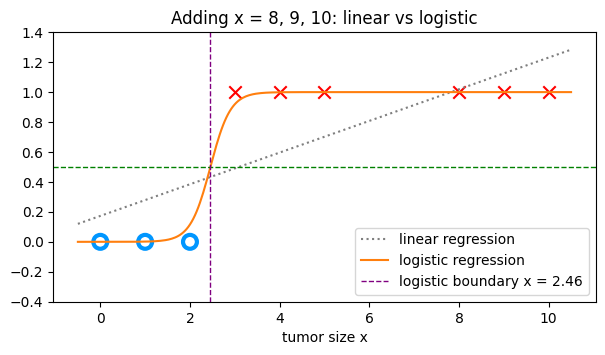

In [25]:
X_more = x_more.reshape(-1, 1)
w_m, b_m, _ = gradient_descent(X_more, y_more, np.zeros(1), 0., alpha=0.1, num_iters=10000, verbose=False)
w_lin, b_lin = fit_line(x_more, y_more)

print("targets:            ", y_more)
print("linear + threshold: ", (w_lin * x_more + b_lin >= 0.5).astype(int))
print("logistic regression:", predict(X_more, w_m, b_m))

xs = np.linspace(-0.5, 10.5, 300)
fig, ax = plt.subplots(1, 1, figsize=(7, 3.5))
ax.plot(xs, w_lin * xs + b_lin, c='tab:gray', ls=':', label="linear regression")
ax.plot(xs, sigmoid(w_m[0] * xs + b_m), c='tab:orange', label="logistic regression")
ax.axhline(0.5, c='g', ls='--', lw=1)
ax.axvline(-b_m / w_m[0], c='purple', ls='--', lw=1, label=f"logistic boundary x = {-b_m / w_m[0]:.2f}")
ax.scatter(x_more[y_more == 1], y_more[y_more == 1], marker='x', s=80, c='red')
ax.scatter(x_more[y_more == 0], y_more[y_more == 0], marker='o', s=100,
           facecolors='none', edgecolors='#0096ff', lw=3)
ax.set_xlabel("tumor size x"); ax.set_ylim(-0.4, 1.4); ax.legend(loc="lower right")
ax.set_title("Adding x = 8, 9, 10: linear vs logistic"); plt.show()

**Observation.** The far-away points barely move the logistic boundary. They are already predicted correctly with $f \approx 1$, so they add almost nothing to the loss or the gradient. Logistic regression keeps every prediction correct, including $x = 3$.

## 8. Logistic regression with scikit-learn

- `LogisticRegression().fit(X, y)` trains the model.
- `.predict(X)` returns classes (threshold 0.5); `.predict_proba(X)[:, 1]` returns $f_{\mathbf{w},b}(\mathbf{x})$.
- `.score(X, y)` returns the **accuracy**, the fraction of examples predicted correctly.

In [26]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_train)
print("Prediction on training set:", y_pred)
print("Accuracy on training set:  ", lr_model.score(X_train, y_train))   # expected 1.0

Prediction on training set: [0 0 0 1 1 1]
Accuracy on training set:   1.0


In [27]:
w_sk, b_sk = lr_model.coef_[0], lr_model.intercept_[0]
print(f"sklearn parameters: w: {w_sk}, b: {b_sk:.3f}")
print(f"our GD  parameters: w: {w_out}, b: {b_out:.3f}")

# predict_proba matches our own sigmoid(X @ w + b) using sklearn's parameters
print("predict_proba matches sigmoid(X @ w + b):",
      np.allclose(lr_model.predict_proba(X_train)[:, 1], predict_proba(X_train, w_sk, b_sk)))

# with (almost) no regularization the parameters grow large, like ours
lr_big_C = LogisticRegression(C=1e4, max_iter=10000).fit(X_train, y_train)
print(f"sklearn, C=1e4:     w: {lr_big_C.coef_[0]}, b: {lr_big_C.intercept_[0]:.3f}")

sklearn parameters: w: [0.904 0.736], b: -2.334
our GD  parameters: w: [5.281 5.078], b: -14.222
predict_proba matches sigmoid(X @ w + b): True
sklearn, C=1e4:     w: [9.845 9.86 ], b: -27.262


**Observation.** Both models get 100% training accuracy, but sklearn's weights are much **smaller** than ours. That is because `LogisticRegression` uses **L2 regularization by default** (`C=1.0`; a smaller `C` means stronger regularization), which keeps the weights small. With `C` very large the weights grow, as ours do. Regularization is covered next in the course.

## 9. Key takeaways

**Key takeaways:**
- Classification predicts a class ($y \in \{0, 1\}$). Linear regression is a poor fit: its output is not limited to $[0,1]$, and one extreme example can move the threshold.
- The **sigmoid** $g(z) = 1/(1+e^{-z})$ maps any $z$ into $(0,1)$. Logistic regression is $f_{\mathbf{w},b}(\mathbf{x}) = g(\mathbf{w}\cdot\mathbf{x}+b)$, read as $P(y=1 \mid \mathbf{x})$.
- Predict $y=1$ when $f \ge 0.5$, which is the same as $z \ge 0$. The **decision boundary** is $\mathbf{w}\cdot\mathbf{x}+b = 0$. Polynomial features make it a curve.
- Squared error + sigmoid gives a **non-convex** cost. The **logistic loss** $-y\log f - (1-y)\log(1-f)$ gives a convex cost that suits gradient descent.
- **Loss** = one example; **cost** = average over the training set.
- The gradient-descent update looks the same as linear regression's; only $f$ changes.
- scikit-learn's `LogisticRegression` does all of this in a few lines, and by default it adds L2 regularization.